<a href="https://colab.research.google.com/github/tciodaro/GRLCDDR1C1-N2-L2-PB/blob/main/topicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Topic Analysis with NMF on 20 Newsgroups Dataset

This notebook demonstrates how to perform topic modeling using Non-negative Matrix Factorization (NMF) on the 20 newsgroups dataset. We will pre-process the text with TF-IDF, and then apply NMF. The best NMF parameters will be selected using `GridSearchCV` and evaluated with Silhouette and Coherence scores.

In [60]:
# !pip install gensim nltk pyldavis

In [61]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [87]:
import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score
import numpy as np

# For coherence score (requires gensim and nltk)
# pip install gensim nltk
import nltk
# nltk.download('punkt')
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from nltk.tokenize import word_tokenize

print("Libraries loaded.")

flag_load20 = True
n_samples_per_class = 800

Libraries loaded.


### 1. Load and Split the Dataset

We will load the 20 newsgroups dataset and split it into 80% training and 20% testing data.

In [88]:
# Load the 20 newsgroups dataset
categories = [
  # 'alt.atheism',
  # 'comp.graphics',
  'comp.os.ms-windows.misc',
  # 'comp.sys.ibm.pc.hardware',
  # 'comp.sys.mac.hardware',
  # 'comp.windows.x',
  # 'misc.forsale',
  # 'rec.autos',
  'rec.motorcycles',
  # 'rec.sport.baseball',
  # 'rec.sport.hockey',
  # 'sci.crypt',
  # 'sci.electronics',
  # 'sci.med',
  'sci.space',
  # 'soc.religion.christian',
  'talk.politics.guns',
  # 'talk.politics.mideast',
  # 'talk.politics.misc',
  # 'talk.religion.misc'
]
def load20newsgroups(categories=None):
  newsgroups = fetch_20newsgroups(subset='train', categories=categories , remove=('headers', 'footers', 'quotes'))
  data = newsgroups.data
  target = newsgroups.target
  return data, target






In [89]:
import pandas as pd

def loadHateBR(n_samples=None):
  # Use the raw GitHub URL for direct CSV access
  df = pd.read_csv('https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/master/preprocessed/pre-processed.csv', sep=',')

  # Assuming 'text' column contains the document text and 'label' is the target.
  # Adjust column names if they are different in the actual dataset.

  if n_samples is not None:
    # Group by label and sample n_samples from each class
    df = df.groupby('label').apply(lambda x: x.sample(n=min(len(x), n_samples), random_state=42)).reset_index(drop=True)

  data = df['preprocessed_news'].values
  target = (df['label'] == 'true').astype(int).values
  return data, target

In [98]:

if flag_load20:
  data, target = load20newsgroups(categories=categories)
else:
  data, target = loadHateBR(n_samples=n_samples_per_class)


print(f"Total documents: {len(data)}")
print(f"Total categories: {np.unique(target).shape[0]}")

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.3, random_state=42)

print(f"Training documents: {len(X_train)}")
print(f"Testing documents: {len(X_test)}")

Total documents: 2328
Total categories: 4
Training documents: 1629
Testing documents: 699


### 2. Build Pipeline and Perform GridSearchCV for NMF Topic Modeling

We will construct a `Pipeline` consisting of `CountVectorizer` and `NMF`. `GridSearchCV` will be used to explore different parameter combinations for these components, optimizing for the Silhouette Score. The Silhouette Score will be calculated using a custom scorer function, assigning each document to its most dominant NMF topic.

In [111]:
# Define the custom silhouette scorer function for NMF
def nmf_silhouette_scorer(estimator, X, y=None):
    """
    Custom scorer for GridSearchCV to calculate the Silhouette Score
    based on NMF's document-topic distribution.
    """
    X_transformed = estimator.named_steps['vectorizer'].transform(X)

    # Get the NMF model and transform the data to get document-topic distributions (W)
    nmf_model = estimator.named_steps['nmf']
    W = nmf_model.transform(X_transformed)

    # Assign each document to its most dominant topic for clustering labels
    labels = np.argmax(W, axis=1)

    # Check if there are at least 2 unique labels, which is required for silhouette_score
    if len(np.unique(labels)) < 2:
        # If not enough clusters are formed, return a very low score
        return -1.0 # Silhouette score ranges from -1 to 1

    # Calculate and return the silhouette score
    return silhouette_score(W, labels, metric='euclidean')

# Create the machine learning pipeline
pipeline = Pipeline([
    # ('vectorizer', CountVectorizer(stop_words='english', max_df=0.95, min_df=0.05)),
    ('vectorizer', TfidfVectorizer(stop_words='english', max_df=0.95, min_df=0.05)),
    ('nmf', NMF(init='nndsvda', max_iter=200, random_state=42))
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'vectorizer__max_features': [1000], # Max number of features (bag-of-words)
    'nmf__n_components': [2, 3, 4, 5, 6, 7, 8]       # Number of topics for NMF
    # 'nmf__n_components': [5]       # Number of topics for NMF
}

# Initialize GridSearchCV with the pipeline and custom scorer
# cv=3 for 3-fold cross-validation
# verbose=2 to display progress
# n_jobs=-1 to use all available CPU cores for parallel processing
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring=nmf_silhouette_scorer,
    refit=True,
    return_train_score=True,
    verbose=2,
    n_jobs=-1
)

print("Starting GridSearchCV. This may take some time...")

# Fit GridSearchCV on the training data
# y_train is passed but not directly used by our custom scorer, it's a standard argument for GridSearchCV's fit method.
grid_search.fit(X_train, y_train)

print("\nGridSearchCV complete!")

# Display the best parameters and the corresponding silhouette score
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation silhouette score:", grid_search.best_score_)

# Store the best model found by GridSearchCV
best_pipeline = grid_search.best_estimator_
print("Best pipeline stored in 'best_pipeline'.")

Starting GridSearchCV. This may take some time...
Fitting 5 folds for each of 7 candidates, totalling 35 fits

GridSearchCV complete!
Best parameters found: {'nmf__n_components': 2, 'vectorizer__max_features': 1000}
Best cross-validation silhouette score: 0.5834233710903818
Best pipeline stored in 'best_pipeline'.


In [112]:
# Topicos por documento
estimator = grid_search.best_estimator_
X_transformed = estimator.named_steps['vectorizer'].transform(X_train)
# Get the NMF model and transform the data to get document-topic distributions (W)
nmf_model = estimator.named_steps['nmf']
W = nmf_model.transform(X_transformed)
# Assign each document to its most dominant topic for clustering labels
y_topic = np.argmax(W, axis=1)

<ErrorbarContainer object of 3 artists>

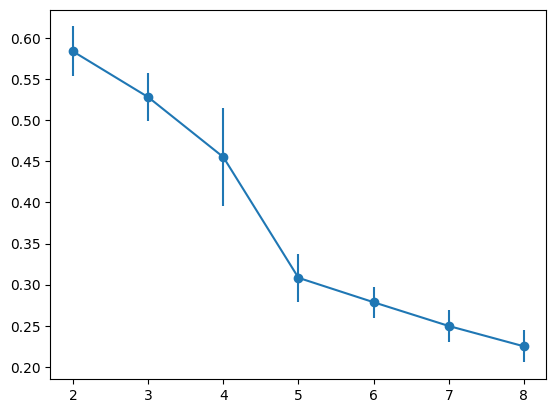

In [113]:
import matplotlib.pyplot as plt


y = grid_search.cv_results_['mean_test_score']
y_err = grid_search.cv_results_['std_test_score']
x = param_grid['nmf__n_components']


plt.errorbar(x, y, y_err, fmt='-o')


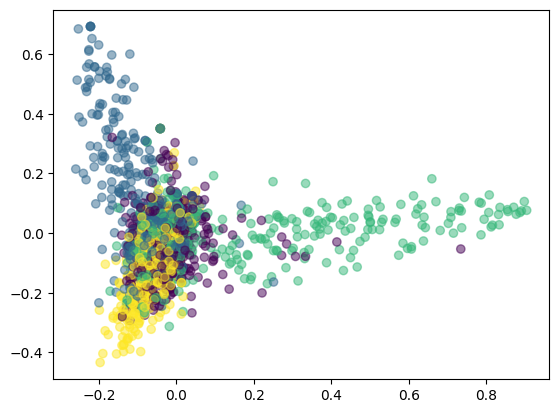

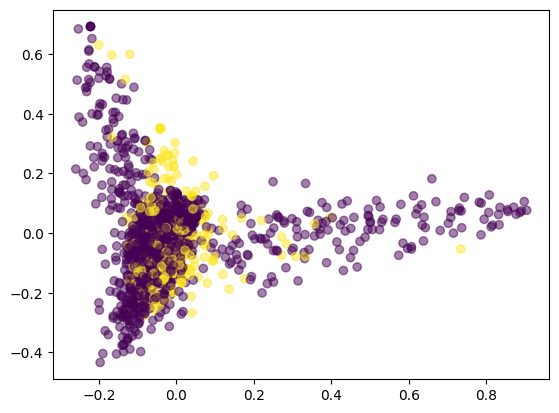

In [114]:
from sklearn.decomposition import PCA

pca_model = PCA(n_components=10)
X_train_pca = pca_model.fit_transform(best_pipeline.named_steps['vectorizer'].transform(X_train))

i1, i2 = 1, 2

plt.figure()
plt.scatter(X_train_pca[:, i1], X_train_pca[:, i2], c=y_train, cmap='viridis', alpha=0.5)

plt.figure()

plt.scatter(X_train_pca[:, i1], X_train_pca[:, i2], c=y_topic, cmap='viridis', alpha=0.5)


              precision    recall  f1-score   support

           0       0.12      0.39      0.19       415
           1       0.06      0.05      0.05       426
           2       0.00      0.00      0.00       400
           3       0.00      0.00      0.00       388

    accuracy                           0.11      1629
   macro avg       0.05      0.11      0.06      1629
weighted avg       0.05      0.11      0.06      1629

[[160 255   0   0]
 [406  20   0   0]
 [371  29   0   0]
 [372  16   0   0]]


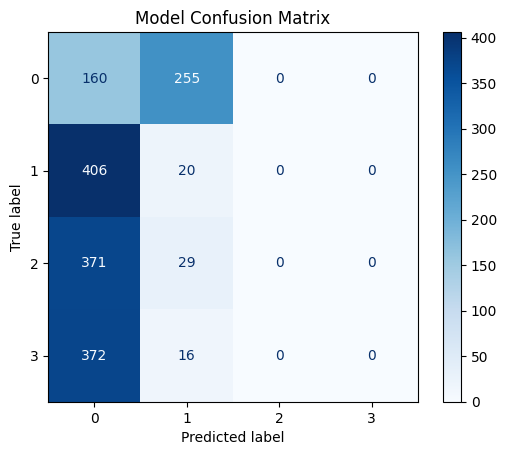

In [117]:
from sklearn import metrics

print(metrics.classification_report(y_train, y_topic))

cm = metrics.confusion_matrix(y_train, y_topic)
print(cm)

disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Model Confusion Matrix")
plt.show()

### 3. Analyze Best Model and Calculate Coherence Score

Now that `GridSearchCV` has identified the best NMF model, we will inspect the topics it found and calculate the coherence score. The coherence score, along with the silhouette score used in `GridSearchCV`, provides a comprehensive evaluation of topic quality.

In [120]:
# Install gensim and nltk if not already installed
import subprocess
import sys
import gensim
import nltk
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from nltk.tokenize import word_tokenize

print("Gensim and NLTK are ready.")

# Extract the best NMF model and TF-IDF vectorizer from the best_pipeline
best_tfidf = best_pipeline.named_steps['vectorizer']
best_nmf = best_pipeline.named_steps['nmf']

feature_names = best_tfidf.get_feature_names_out()

# Function to display top words for each topic
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx+1}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
    print("\n")

# Display the top words for each topic from the best NMF model
no_top_words = 10
print(f"Top {no_top_words} words per topic found by the best NMF model:")
display_topics(best_nmf, feature_names, no_top_words)

# --- Calculate Coherence Score ---

# Tokenize the training data for Gensim
tokenized_data = [word_tokenize(doc.lower()) for doc in X_train]

# Create a Gensim dictionary and corpus
dictionary = Dictionary(tokenized_data)
corpus = [dictionary.doc2bow(text) for text in tokenized_data]

# Get the topic-word distribution from the best NMF model
# Convert NMF components (topic-word matrix) to a list of (word_id, probability) tuples
def get_gensim_topics(nmf_model, feature_names, dictionary):
    gensim_topics = []
    for topic_idx, topic in enumerate(nmf_model.components_):
        # Get top words for this topic
        top_feature_indices = topic.argsort()[:-no_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_feature_indices]
        gensim_topics.append(top_words)
    return gensim_topics

gensim_topics = get_gensim_topics(best_nmf, feature_names, dictionary)

# Calculate Coherence Score
coherence_model_nmf = CoherenceModel(
    topics=gensim_topics,
    texts=tokenized_data,
    dictionary=dictionary,
    coherence='u_mass'
)
coherence_nmf = coherence_model_nmf.get_coherence()

print(f"Coherence Score for the best NMF model: {coherence_nmf:.4f}")

print("\nAnalysis complete for the best model.")

Gensim and NLTK are ready.
Top 10 words per topic found by the best NMF model:
Topic 1:
just like don people space think know bike gun time
Topic 2:
windows thanks file use program problem using does help know


Coherence Score for the best NMF model: -2.1888

Analysis complete for the best model.


### 4. Evaluate the Best Model on Test Data

We will now apply the best trained pipeline to the unseen test data (`X_test`) and calculate both the Silhouette and Coherence scores for the topics identified in this set.

In [121]:
# Transform the test data using the best pipeline's vectorizer and NMF steps
# First, transform with Vectorizer
X_test_vectorizer = best_pipeline.named_steps['vectorizer'].transform(X_test)

# Then, apply the NMF model to get document-topic distributions for the test set
W_test = best_pipeline.named_steps['nmf'].transform(X_test_vectorizer)

# --- Calculate Silhouette Score for Test Data ---

# Assign each test document to its most dominant topic for clustering labels
labels_test = np.argmax(W_test, axis=1)

# Check if there are at least 2 unique labels for silhouette_score
if len(np.unique(labels_test)) >= 2:
    silhouette_test_score = silhouette_score(W_test, labels_test, metric='euclidean')
    print(f"Silhouette Score for Test Data: {silhouette_test_score:.4f}")
else:
    print("Not enough unique topic labels in the test set to calculate Silhouette Score.")

# --- Calculate Coherence Score for Test Data ---

# Tokenize the test data for Gensim
tokenized_data_test = [word_tokenize(doc.lower()) for doc in X_test]

# Create a Gensim dictionary for the test data (or reuse the training dictionary)
# Reusing the training dictionary is generally better for consistency
# dictionary_test = Dictionary(tokenized_data_test)
# corpus_test = [dictionary.doc2bow(text) for text in tokenized_data_test]

# Get the topic-word distribution (gensim_topics) which was already derived from the best NMF model
# and is consistent for both train and test evaluation of topic quality.

coherence_model_nmf_test = CoherenceModel(
    topics=gensim_topics,
    texts=tokenized_data_test,
    dictionary=dictionary,
    coherence='u_mass' # {'u_mass', 'c_v', 'c_uci', 'c_npmi'}
)
coherence_nmf_test = coherence_model_nmf_test.get_coherence()

print(f"Coherence Score for Test Data: {coherence_nmf_test:.4f}")

print("\nEvaluation on test data complete.")

Silhouette Score for Test Data: 0.5821
Coherence Score for Test Data: -2.2829

Evaluation on test data complete.


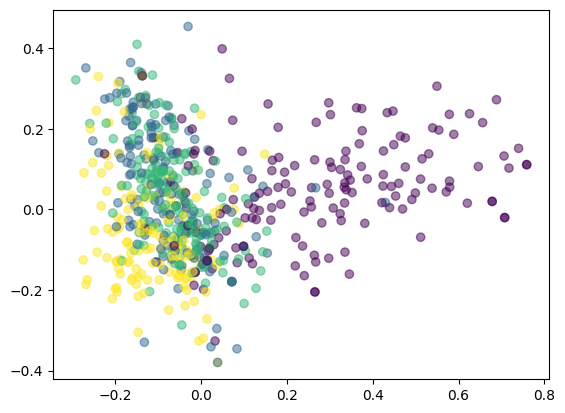

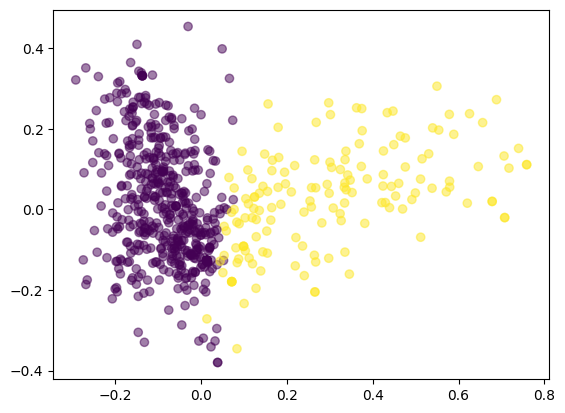

In [122]:
from sklearn.decomposition import PCA


X_test_pca = pca_model.transform(best_pipeline.named_steps['vectorizer'].transform(X_test))

i1, i2 = 0, 3

plt.figure()
plt.scatter(X_test_pca[:, i1], X_test_pca[:, i2], c=y_test, cmap='viridis', alpha=0.5)

plt.figure()

plt.scatter(X_test_pca[:, i1], X_test_pca[:, i2], c=labels_test, cmap='viridis', alpha=0.5)


              precision    recall  f1-score   support

           0       0.10      0.32      0.16       176
           1       0.10      0.09      0.09       172
           2       0.00      0.00      0.00       193
           3       0.00      0.00      0.00       158

    accuracy                           0.10       699
   macro avg       0.05      0.10      0.06       699
weighted avg       0.05      0.10      0.06       699

[[ 57 119   0   0]
 [157  15   0   0]
 [180  13   0   0]
 [153   5   0   0]]


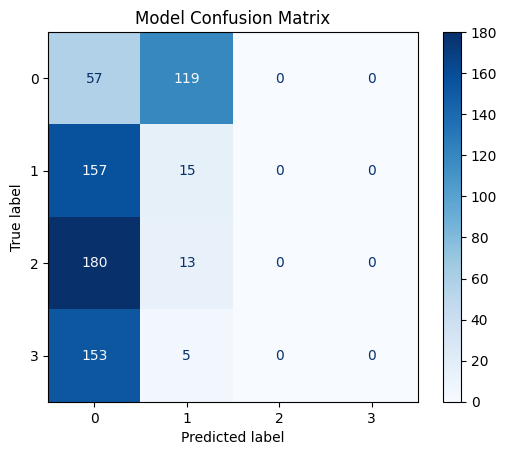

In [123]:
from sklearn import metrics

print(metrics.classification_report(y_test, labels_test))

cm = metrics.confusion_matrix(y_test, labels_test)
print(cm)

disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Model Confusion Matrix")
plt.show()

# Grid-Search NMF com Métrica Coerência

In [124]:
def coherence_scorer_u_mass(estimator, X, y=None):
    """
    Custom scorer for GridSearchCV to calculate the Coherence Score (u_mass)
    based on NMF topics.

    GridSearchCV maximizes the score, and for u_mass, higher (less negative)
    values are better, so we return the raw u_mass score.
    """
    # 1. Get the NMF model and its components (topic-word distribution)
    model = estimator.named_steps['model']
    best_vectorizer = estimator.named_steps['vectorizer']

    feature_names = best_vectorizer.get_feature_names_out()

    # Number of top words to consider for topic representation
    no_top_words = 10 # This matches the previous usage for gensim_topics

    # Get gensim_topics from the NMF model components
    gensim_topics_local = []
    for topic_idx, topic in enumerate(model.components_):
        top_feature_indices = topic.argsort()[:-no_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_feature_indices]
        gensim_topics_local.append(top_words)

    # 2. Tokenize the input text `X` (validation fold) for Gensim
    tokenized_X_for_coherence = [word_tokenize(doc.lower()) for doc in X]

    # 3. Calculate Coherence Score (u_mass)
    # The `dictionary` is assumed to be globally available, created from X_train.
    # This ensures a consistent vocabulary for coherence calculation.
    # Check if the validation fold `X` is empty after tokenization
    if not tokenized_X_for_coherence:
        return -np.inf # Return a very low score if no text to evaluate coherence

    coherence_model = CoherenceModel(
        topics=gensim_topics_local,
        texts=tokenized_X_for_coherence, # Use tokenized X for this fold
        dictionary=dictionary, # Use dictionary from overall training data
        coherence='u_mass'
    )
    coherence_score_u_mass = coherence_model.get_coherence()

    # GridSearchCV maximizes the score. For u_mass, higher (less negative) values are better.
    return coherence_score_u_mass


In [139]:

# Create the machine learning pipeline
pipeline = Pipeline([
    # ('vectorizer', CountVectorizer(stop_words='english')),
    ('vectorizer', TfidfVectorizer(stop_words='english')),
    ('model', NMF(init='nndsvda', max_iter=200, random_state=42))
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'vectorizer__max_features': [2000], # Max number of features for TF-IDF
    'model__n_components': [2, 3, 4, 5, 6, 7, 8]       # Number of topics for NMF
    # 'nmf__n_components': [5]       # Number of topics for NMF
}

# Initialize GridSearchCV with the pipeline and custom scorer
# cv=3 for 3-fold cross-validation
# verbose=2 to display progress
# n_jobs=-1 to use all available CPU cores for parallel processing
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring=coherence_scorer_u_mass,
    refit=True,
    return_train_score=True,
    verbose=2,
    n_jobs=-1
)

print("Starting GridSearchCV. This may take some time...")

# Fit GridSearchCV on the training data
# y_train is passed but not directly used by our custom scorer, it's a standard argument for GridSearchCV's fit method.
grid_search.fit(X_train, y_train)

print("\nGridSearchCV complete!")

# Display the best parameters and the corresponding silhouette score
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation coerencia score:", grid_search.best_score_)

# Store the best model found by GridSearchCV
best_pipeline = grid_search.best_estimator_
print("Best pipeline stored in 'best_pipeline'.")

Starting GridSearchCV. This may take some time...
Fitting 5 folds for each of 7 candidates, totalling 35 fits

GridSearchCV complete!
Best parameters found: {'model__n_components': 3, 'vectorizer__max_features': 2000}
Best cross-validation coerencia score: -4.624709377456953
Best pipeline stored in 'best_pipeline'.


In [146]:
# Topicos por documento
estimator = grid_search.best_estimator_
X_transformed = estimator.named_steps['vectorizer'].transform(X_train)
feature_names = estimator.named_steps['vectorizer'].get_feature_names_out()
# Get the NMF model and transform the data to get document-topic distributions (W)
nmf_model = estimator.named_steps['model']
W = nmf_model.transform(X_transformed)
# Assign each document to its most dominant topic for clustering labels
y_topic = np.argmax(W, axis=1)

<ErrorbarContainer object of 3 artists>

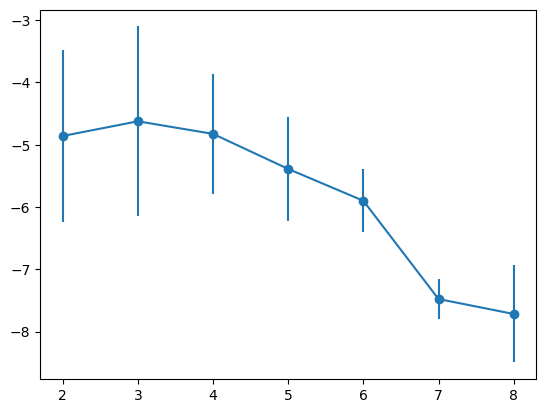

In [141]:
import matplotlib.pyplot as plt


y = grid_search.cv_results_['mean_test_score']
y_err = grid_search.cv_results_['std_test_score']
x = param_grid['model__n_components']

plt.errorbar(x, y, y_err, fmt='-o')


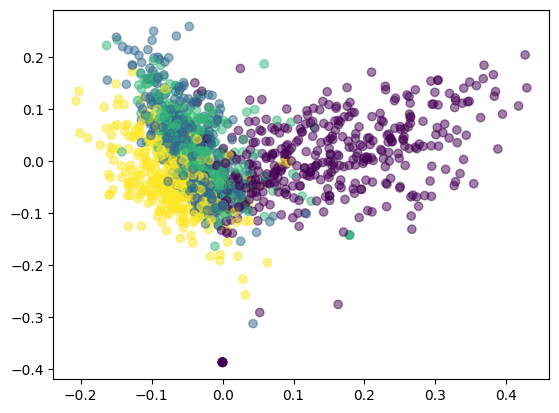

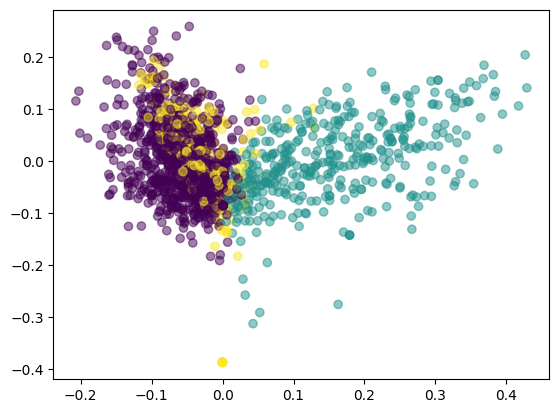

In [142]:
from sklearn.decomposition import PCA

pca_model = PCA(n_components=10)
X_train_pca = pca_model.fit_transform(best_pipeline.named_steps['vectorizer'].transform(X_train))

i1, i2 = 0, 3

plt.figure()
plt.scatter(X_train_pca[:, i1], X_train_pca[:, i2], c=y_train, cmap='viridis', alpha=0.5)

plt.figure()

plt.scatter(X_train_pca[:, i1], X_train_pca[:, i2], c=y_topic, cmap='viridis', alpha=0.5)



              precision    recall  f1-score   support

           0       0.06      0.14      0.08       415
           1       0.05      0.04      0.04       426
           2       0.86      0.58      0.70       400
           3       0.00      0.00      0.00       388

    accuracy                           0.19      1629
   macro avg       0.24      0.19      0.21      1629
weighted avg       0.24      0.19      0.20      1629

[[ 58 338  19   0]
 [398  18  10   0]
 [149  17 234   0]
 [365  14   9   0]]


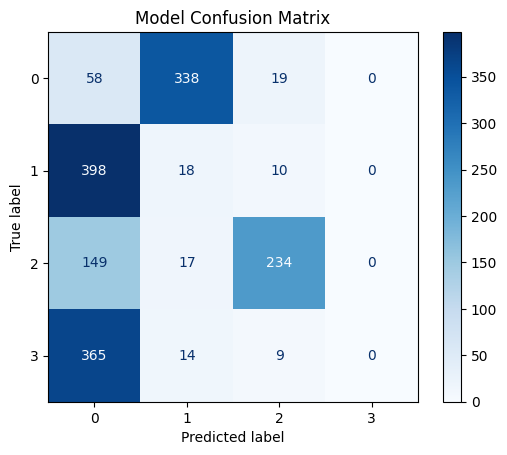

In [143]:


from sklearn import metrics

print(metrics.classification_report(y_train, y_topic))

cm = metrics.confusion_matrix(y_train, y_topic)
print(cm)

disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Model Confusion Matrix")
plt.show()

In [148]:

# Function to display top words for each topic
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx+1}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
    print("\n")

# Display the top words for each topic from the best NMF model
no_top_words = 10
print(f"Top {no_top_words} words per topic found by the best NMF model:")
display_topics(nmf_model, feature_names, no_top_words)


Top 10 words per topic found by the best NMF model:
Topic 1:
don just people bike like gun think know right good
Topic 2:
windows file files dos thanks card drivers driver use problem
Topic 3:
space nasa shuttle launch program lunar earth sci orbit moon




In [149]:
import joblib
joblib.dump(best_pipeline, 'modelo-topicos-nmf.pkl')


['modelo-topicos-nmf.pkl']

# LDA

In [170]:

# Create the machine learning pipeline
pipeline = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')),
    ('model', LatentDirichletAllocation(random_state=42, max_iter=20))
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'vectorizer__max_features': [2000], # Max number of features for TF-IDF
    'model__n_components': [5, 6, 7, 8]       # Number of topics for NMF
    # 'nmf__n_components': [5]       # Number of topics for NMF
}

# Initialize GridSearchCV with the pipeline and custom scorer
# cv=3 for 3-fold cross-validation
# verbose=2 to display progress
# n_jobs=-1 to use all available CPU cores for parallel processing
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring=coherence_scorer_u_mass,
    refit=True,
    return_train_score=True,
    verbose=2,
    n_jobs=-1
)

print("Starting GridSearchCV. This may take some time...")

# Fit GridSearchCV on the training data
# y_train is passed but not directly used by our custom scorer, it's a standard argument for GridSearchCV's fit method.
grid_search.fit(X_train, y_train)

print("\nGridSearchCV complete!")

# Display the best parameters and the corresponding silhouette score
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation coerencia score:", grid_search.best_score_)

# Store the best model found by GridSearchCV
best_pipeline = grid_search.best_estimator_
print("Best pipeline stored in 'best_pipeline'.")

Starting GridSearchCV. This may take some time...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

GridSearchCV complete!
Best parameters found: {'model__n_components': 5, 'vectorizer__max_features': 2000}
Best cross-validation coerencia score: -4.907610433997623
Best pipeline stored in 'best_pipeline'.


In [153]:
# Topicos por documento
estimator = grid_search.best_estimator_
X_transformed = estimator.named_steps['vectorizer'].transform(X_train)
feature_names = estimator.named_steps['vectorizer'].get_feature_names_out()
# Get the NMF model and transform the data to get document-topic distributions (W)
lda_model = estimator.named_steps['model']
W = lda_model.transform(X_transformed)
# Assign each document to its most dominant topic for clustering labels
y_topic = np.argmax(W, axis=1)

<ErrorbarContainer object of 3 artists>

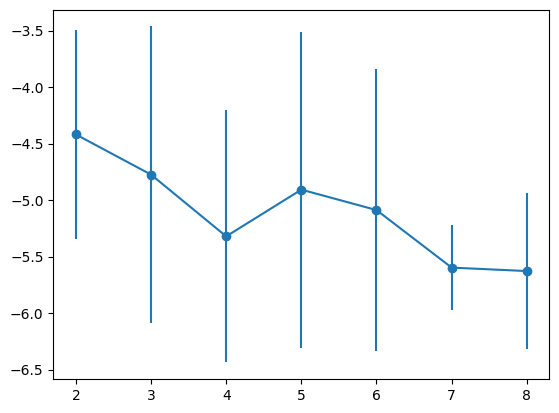

In [154]:
y = grid_search.cv_results_['mean_test_score']
y_err = grid_search.cv_results_['std_test_score']
x = param_grid['model__n_components']
plt.errorbar(x, y, y_err, fmt='-o')

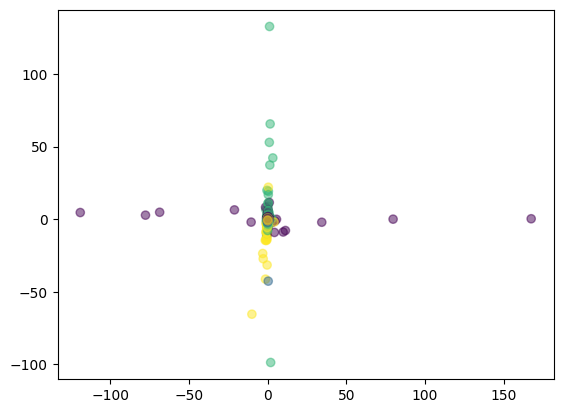

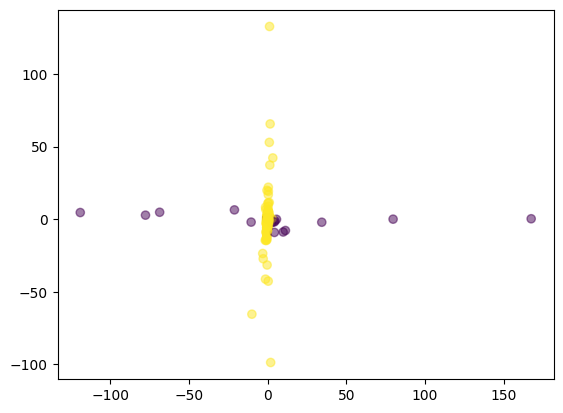

In [165]:
from sklearn.decomposition import PCA
pca_model = PCA(n_components=10)


xvec = best_pipeline.named_steps['vectorizer'].transform(X_train)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
xvec = scaler.fit_transform(xvec.todense().tolist())

X_train_pca = pca_model.fit_transform(xvec)

i1, i2 = 7, 8

plt.figure()
plt.scatter(X_train_pca[:, i1], X_train_pca[:, i2], c=y_train, cmap='viridis', alpha=0.5)

plt.figure()
plt.scatter(X_train_pca[:, i1], X_train_pca[:, i2], c=y_topic, cmap='viridis', alpha=0.5)



              precision    recall  f1-score   support

           0       0.43      0.07      0.13       415
           1       0.26      0.97      0.42       426
           2       0.00      0.00      0.00       400
           3       0.00      0.00      0.00       388

    accuracy                           0.27      1629
   macro avg       0.17      0.26      0.14      1629
weighted avg       0.18      0.27      0.14      1629

[[ 31 384   0   0]
 [ 14 412   0   0]
 [ 15 385   0   0]
 [ 12 376   0   0]]


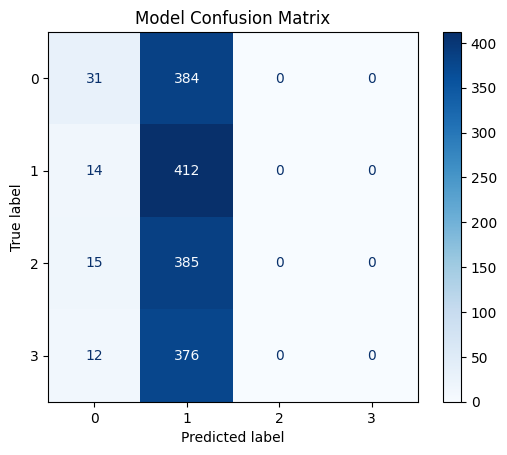

In [166]:


from sklearn import metrics

print(metrics.classification_report(y_train, y_topic))

cm = metrics.confusion_matrix(y_train, y_topic)
print(cm)

disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Model Confusion Matrix")
plt.show()

In [167]:

# Function to display top words for each topic
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx+1}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
    print("\n")

# Display the top words for each topic from the best NMF model
no_top_words = 20
print(f"Top {no_top_words} words per topic found by the best NMF model:")
display_topics(lda_model, feature_names, no_top_words)


Top 20 words per topic found by the best NMF model:
Topic 1:
ax max g9v pl b8f a86 34u 1t 75u 1d9 bhj 145 3t giz cx 2di 0t 2tm 7ey ah
Topic 2:
space like gun file just don windows people use know think time nasa new good right make does bike edu




In [168]:
import joblib
joblib.dump(best_pipeline, 'modelo-topicos-lda.pkl')


['modelo-topicos-lda.pkl']

In [169]:
import pyLDAvis
import pyLDAvis.lda_model

# Ensure pyLDAvis is installed
# !pip install pyldavis

# Get the best LDA model and vectorizer from the best_pipeline
lda_model_for_vis = best_pipeline.named_steps['model']
vectorizer_for_vis = best_pipeline.named_steps['vectorizer']

# 4. Vocabulary
vocab = vectorizer_for_vis.get_feature_names_out()
# 5. Term frequency (total count of each term in the corpus)
term_frequency = vectorizer_for_vis.transform(X_train).sum(axis=0).A1

# Prepare the data for pyLDAvis
lda_data = pyLDAvis.lda_model.prepare(
    lda_model=lda_model_for_vis,
    dtm=vectorizer_for_vis.transform(X_train),
    vectorizer=vectorizer_for_vis,
    vocab=vocab,
    term_frequency=term_frequency
)

# Display the visualization
pyLDAvis.display(lda_data)
